In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\admin\Documents\My_projects\AQI_project\data\final_integrated_data.csv')
df = df.sort_values("Timestamp").reset_index(drop= True)
df.shape

(29222, 52)

In [4]:
y = df["PM2.5 (µg/m³)"]
y.shape

(29222,)

In [5]:
# Experiment #1 features - CAMS composition

cams_composition = ['co', 'aermr04', 'aermr05', 'aermr06', 'aermr09', 'aermr07', 'aermr10',
       'aermr08', 'no2', 'no', 'go3','so2']

X1 = df[cams_composition]
X1.shape

(29222, 12)

In [6]:
# Experiment #2 features - CAMS composition + meteorology

cams_meteorology = ['q','t','u10', 'v10', 'd2m', 't2m']

X2 = df[cams_composition + cams_meteorology]
X2.shape

(29222, 18)

In [8]:
# EXPERIMENT 1

from sklearn.model_selection import train_test_split
x1_train,x1_test,y_train,y_test = train_test_split(X1,y,test_size=0.20,shuffle= False)  # don't want to shuffle the data , want to test from the last 2 year data
x1_train.shape,x1_test.shape,y_train.shape,y_test.shape

((23377, 12), (5845, 12), (23377,), (5845,))

In [7]:
# EXPERIMENT 2

from sklearn.model_selection import train_test_split
x2_train,x2_test,y2_train,y2_test = train_test_split(X2,y,test_size=0.20,shuffle= False)
x2_train.shape,x2_test.shape,y2_train.shape,y2_test.shape

((23377, 18), (5845, 18), (23377,), (5845,))

In [47]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
# model creation

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor)
from xgboost import XGBRegressor

In [10]:
models = {
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Gradient Boosting" :GradientBoostingRegressor(random_state=42),
    "AdaBoost" : AdaBoostRegressor(random_state=42),
    "XGBoost" : XGBRegressor(random_state=42)
}

In [11]:
results_exp1 = {}

for name, model in models.items():
    model.fit(x1_train, y_train)
    y_pred = model.predict(x1_test)

    results_exp1[name] = y_pred

In [12]:
results_exp1

{'Decision Tree': array([135.51694678, 135.51694678, 135.51694678, ..., 135.51694678,
        135.51694678, 135.51694678], shape=(5845,)),
 'Random Forest': array([135.45090899, 135.45090899, 135.45090899, ..., 135.45090899,
        135.45090899, 135.45090899], shape=(5845,)),
 'Gradient Boosting': array([135.51711395, 135.51711395, 135.51711395, ..., 135.51711395,
        135.51711395, 135.51711395], shape=(5845,)),
 'AdaBoost': array([167.6900104, 167.6900104, 167.6900104, ..., 167.6900104,
        167.6900104, 167.6900104], shape=(5845,)),
 'XGBoost': array([133.12202, 139.3021 , 199.6083 , ..., 257.51196, 228.46426,
        236.99352], shape=(5845,), dtype=float32)}

In [13]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [16]:
evaluation_exp1 = []

for name, y_pred in results_exp1.items():
    evaluation_exp1.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5
    })

evaluation_exp1 = pd.DataFrame(evaluation_exp1)

evaluation_exp1

,Model,R2,MAE,RMSE
0,Decision Tree,0.006496,88.014614,114.271387
1,Random Forest,0.011067,87.895474,114.008189
2,Gradient Boosting,0.006569,88.008958,114.267173
3,AdaBoost,-0.114946,101.607089,121.054101
4,XGBoost,0.580399,48.805158,74.262714


In [14]:
results_exp2 = {}

for name, model in models.items():
    model.fit(x2_train, y2_train)
    y_pred = model.predict(x2_test)

    results_exp2[name] = y_pred

In [15]:
evaluation_exp2 = []

for name, y_pred in results_exp2.items():
    evaluation_exp2.append({
        "Model": name,
        "R2": r2_score(y2_test, y_pred),
        "MAE": mean_absolute_error(y2_test, y_pred),
        "RMSE": mean_squared_error(y2_test, y_pred) ** 0.5
    })

evaluation_exp2 = pd.DataFrame(evaluation_exp2)

evaluation_exp2

,Model,R2,MAE,RMSE
0,Decision Tree,0.032392,72.394692,112.772274
1,Random Forest,0.540983,52.213248,77.672446
2,Gradient Boosting,0.497771,55.255895,81.246315
3,AdaBoost,0.179256,78.455039,103.861942
4,XGBoost,0.627230,46.642247,69.996014


In [17]:
comparison = evaluation_exp1.merge(
    evaluation_exp2,
    on="Model",
    suffixes=("_Exp1", "_Exp2")
)

comparison.to_csv("Tables/exp1_exp2_evaluation.csv",index = False)
comparison

,Model,R2_Exp1,MAE_Exp1,RMSE_Exp1,R2_Exp2,MAE_Exp2,RMSE_Exp2
0,Decision Tree,0.006496,88.014614,114.271387,0.032392,72.394692,112.772274
1,Random Forest,0.011067,87.895474,114.008189,0.540983,52.213248,77.672446
2,Gradient Boosting,0.006569,88.008958,114.267173,0.497771,55.255895,81.246315
3,AdaBoost,-0.114946,101.607089,121.054101,0.179256,78.455039,103.861942
4,XGBoost,0.580399,48.805158,74.262714,0.627230,46.642247,69.996014


In [57]:
# Hyperparameter tuning - Gridsearch cv

from sklearn.model_selection import GridSearchCV

In [58]:
param_grids = {
    "Decision Tree": {
        "max_depth":[3,5,10,None],
        "min_samples_split" : [2,5,10],
        "min_samples_leaf" : [1,2,3]
    },
    "Random Forest" : {
        "n_estimators" : [100,200],
        "max_depth" : [2,10,None],
        "min_samples_split" : [2,5],
        "min_samples_leaf" : [1,2]
    },
    "Gradient Boosting" : {
        "n_estimators" : [100,200],
        "learning_rate" : [0.05,0.1],
        "max_depth" : [3,5]
    },
    "AdaBoost" : {
        "n_estimators" : [50,100,200],
        "learning_rate" : [0.01,0.1,1.0]
    },
    "XGBoost" : {
        "n_estimators" : [100,200],
        "learning_rate" : [0.05,0.1],
        "max_depth" : [3,5]
    }
}

In [59]:
tuned_models = {}
best_params = {}

for name, model in models.items():
    print(f"Tuning {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    grid_search.fit(x2_train, y2_train)
    
    tuned_models[name] = grid_search.best_estimator_
    best_params[name] = grid_search.best_params_
    
    print("Best parameters:", grid_search.best_params_)
    print()

Tuning Decision Tree...
Best parameters: {'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}

Tuning Random Forest...
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Tuning Gradient Boosting...
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

Tuning AdaBoost...
Best parameters: {'learning_rate': 0.01, 'n_estimators': 100}

Tuning XGBoost...
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}



In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

tuned_evaluation = {}

for name, model in tuned_models.items():
    y_pred = model.predict(x2_test)
    
    r2 = r2_score(y2_test, y_pred)
    mae = mean_absolute_error(y2_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred))
    
    tuned_evaluation[name] = {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

tuned_evaluation

{'Decision Tree': {'R2': 0.554126884921379,
  'MAE': 49.80524967745477,
  'RMSE': np.float64(76.55230268536113)},
 'Random Forest': {'R2': 0.6529667264564931,
  'MAE': 45.381452146981694,
  'RMSE': np.float64(67.53644152295352)},
 'Gradient Boosting': {'R2': 0.6525246208589445,
  'MAE': 44.85409254854317,
  'RMSE': np.float64(67.57944710430989)},
 'AdaBoost': {'R2': 0.5534206577437422,
  'MAE': 51.87722649566024,
  'RMSE': np.float64(76.61290504485524)},
 'XGBoost': {'R2': 0.6563685402458626,
  'MAE': 44.54059822996432,
  'RMSE': np.float64(67.20461138189425)}}

In [61]:
tuned_df = pd.DataFrame(tuned_evaluation).T.reset_index()

tuned_df.columns = ["Model", "R2_Tuned", "MAE_Tuned", "RMSE_Tuned"]

tuned_df

,Model,R2_Tuned,MAE_Tuned,RMSE_Tuned
0,Decision Tree,0.554127,49.805250,76.552303
1,Random Forest,0.652967,45.381452,67.536442
2,Gradient Boosting,0.652525,44.854093,67.579447
3,AdaBoost,0.553421,51.877226,76.612905
4,XGBoost,0.656369,44.540598,67.204611


In [86]:
# comparing exp2 before tuning vs after tuning

comparison_tuning = evaluation_exp2.merge(
    tuned_df,
    on="Model"
)

comparison_tuning.to_csv("Tables/Exp2_evaluation_before_VS_after_tuning.csv",index = False)
comparison_tuning

,Model,R2,MAE,RMSE,R2_Tuned,MAE_Tuned,RMSE_Tuned
0,Decision Tree,0.257475,62.558415,98.788884,0.554127,49.805250,76.552303
1,Random Forest,0.645448,46.149061,68.264162,0.652967,45.381452,67.536442
2,Gradient Boosting,0.640197,45.652413,68.767782,0.652525,44.854093,67.579447
3,AdaBoost,-0.772978,139.633544,152.652640,0.553421,51.877226,76.612905
4,XGBoost,0.629806,46.411764,69.753717,0.656369,44.540598,67.204611


In [63]:
best_model_name = max(
    tuned_evaluation,
    key=lambda name: tuned_evaluation[name]["R2"]
)

best_model = tuned_models[best_model_name]

print("Best Model:", best_model_name)
print("Best Parameters:", best_params[best_model_name])
print("R2:", tuned_evaluation[best_model_name]["R2"])
print("MAE:", tuned_evaluation[best_model_name]["MAE"])
print("RMSE:", tuned_evaluation[best_model_name]["RMSE"])

Best Model: XGBoost
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
R2: 0.6563685402458626
MAE: 44.54059822996432
RMSE: 67.20461138189425


In [80]:
comparison_tuning["R2_Improvement"] = (
    comparison_tuning["R2_Tuned"] - comparison_tuning["R2"]
)

comparison_tuning["MAE_Improvement"] = (
    comparison_tuning["MAE"] - comparison_tuning["MAE_Tuned"]
)

comparison_tuning["RMSE_Improvement"] = (
    comparison_tuning["RMSE"] - comparison_tuning["RMSE_Tuned"]
)

comparison_tuning.to_csv("Tables/Tuning_improvement.csv",index = "False")
comparison_tuning

,Model,R2,MAE,RMSE,R2_Tuned,MAE_Tuned,RMSE_Tuned,R2_Improvement,MAE_Improvement,RMSE_Improvement
0,Decision Tree,0.257475,62.558415,98.788884,0.554127,49.805250,76.552303,0.296652,12.753166,22.236581
1,Random Forest,0.645448,46.149061,68.264162,0.652967,45.381452,67.536442,0.007519,0.767608,0.727720
2,Gradient Boosting,0.640197,45.652413,68.767782,0.652525,44.854093,67.579447,0.012328,0.798320,1.188335
3,AdaBoost,-0.772978,139.633544,152.652640,0.553421,51.877226,76.612905,1.326399,87.756318,76.039734
4,XGBoost,0.629806,46.411764,69.753717,0.656369,44.540598,67.204611,0.026563,1.871165,2.549106


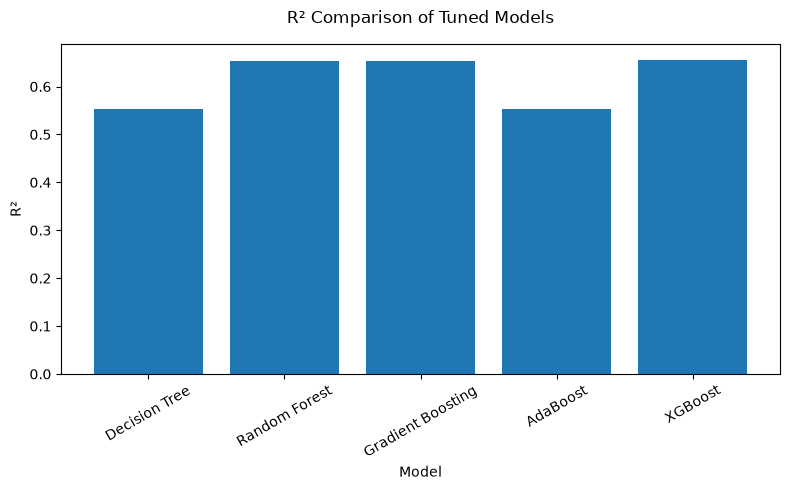

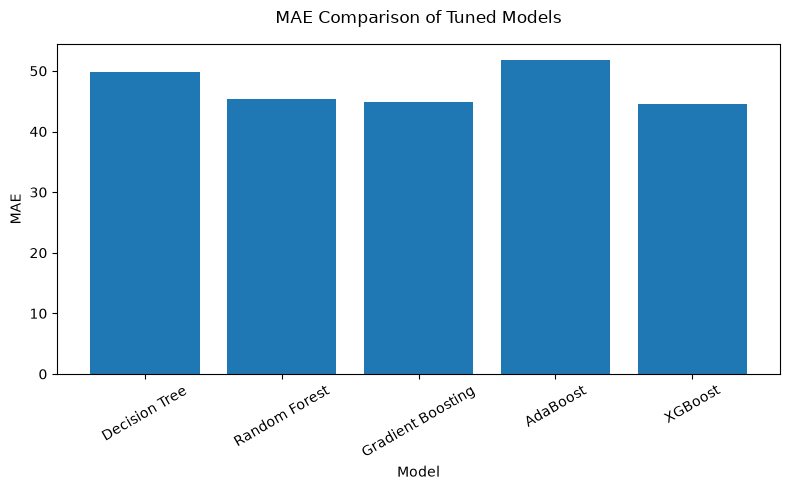

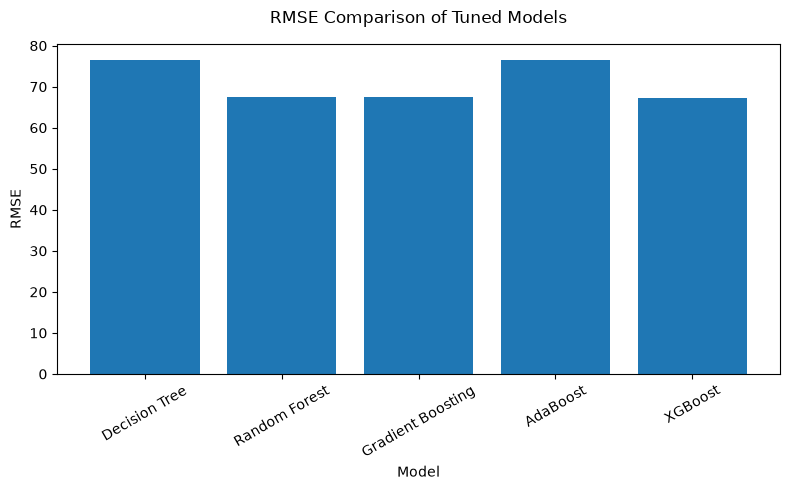

In [65]:
import matplotlib.pyplot as plt

models_tuned = list(tuned_evaluation.keys())
r2_values = [tuned_evaluation[m]["R2"] for m in models_tuned]
mae_values = [tuned_evaluation[m]["MAE"] for m in models_tuned]
rmse_values = [tuned_evaluation[m]["RMSE"] for m in models_tuned]

# R²
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, r2_values)
plt.ylabel("R²")
plt.xlabel("Model")
plt.title("R² Comparison of Tuned Models",pad=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plots/Modelling_plots/R2_comparison_tuned_models.png",dpi = 300,bbox_inches = 'tight')
plt.show()

# MAE
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, mae_values)
plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("MAE Comparison of Tuned Models",pad=15)
plt.xticks(rotation=30)
plt.savefig("plots/Modelling_plots/MAE_comparison_tuned_models.png",dpi = 300,bbox_inches = 'tight')
plt.tight_layout()
plt.show()

# RMSE
plt.figure(figsize=(8, 5))
plt.bar(models_tuned, rmse_values)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Comparison of Tuned Models",pad=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plots/Modelling_plots/RMSE_comparison_tuned_models.png",dpi = 300,bbox_inches = 'tight')
plt.show()

In [81]:
final_results = pd.DataFrame(tuned_evaluation).T.reset_index()

final_results.columns = ["Model", "R2", "MAE", "RMSE"]

final_results = final_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)


final_results.to_csv("Tables/Best_model_sorted.csv",index = False)
final_results

,Model,R2,MAE,RMSE
0,XGBoost,0.656369,44.540598,67.204611
1,Random Forest,0.652967,45.381452,67.536442
2,Gradient Boosting,0.652525,44.854093,67.579447
3,Decision Tree,0.554127,49.805250,76.552303
4,AdaBoost,0.553421,51.877226,76.612905


In [67]:
# XGBoost is our final model... Let's examine its predictions

In [68]:
y2_pred = best_model.predict(x2_test)

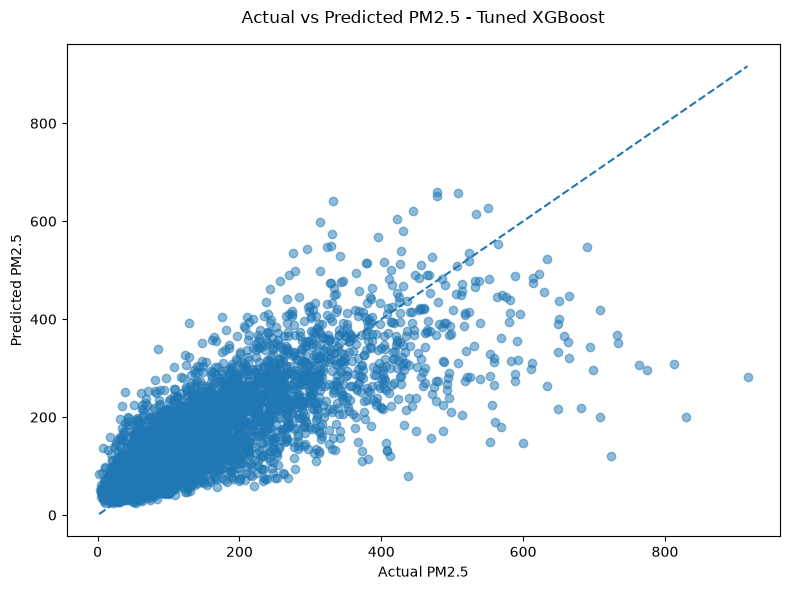

In [69]:
# let's visualize how well our tuned XGBoost predictions match the actual PM2.5 values

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y2_test, y2_pred, alpha=0.5)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 - Tuned XGBoost",pad=15)

# Perfect prediction line
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.savefig("plots/Modelling_plots/Actual_vs_pred_PM2.5_TunedXGB.png",dpi = 300,bbox_inches = 'tight')
plt.show()

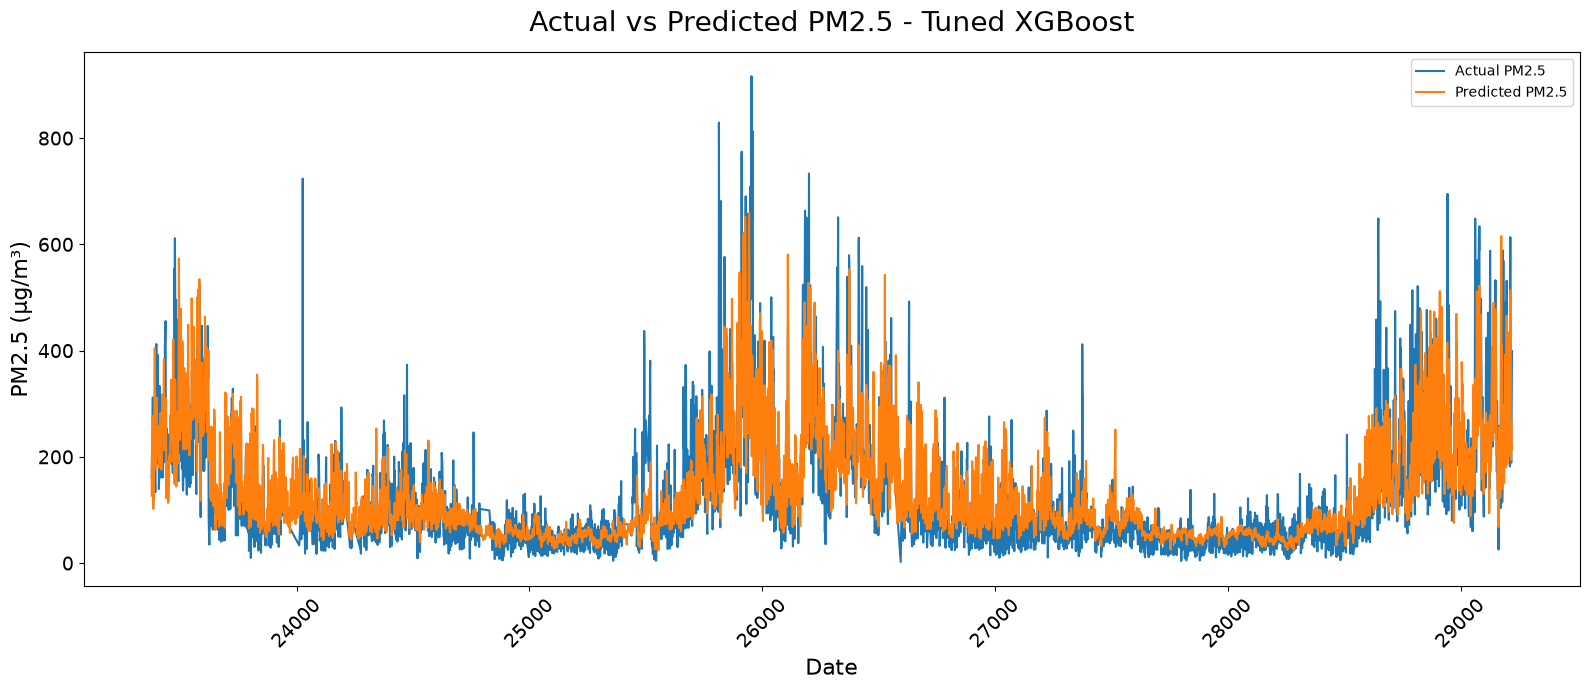

In [84]:
# time series plot

plt.figure(figsize=(16,7))

plt.plot(x2_test.index, y2_test, label="Actual PM2.5")
plt.plot(x2_test.index, y2_pred, label="Predicted PM2.5")

plt.xlabel("Date", fontsize = 16)
plt.ylabel("PM2.5 (µg/m³)", fontsize = 16)
plt.title("Actual vs Predicted PM2.5 - Tuned XGBoost",fontsize = 20,pad=15)
plt.legend()
plt.xticks(fontsize = 14,rotation=45)
plt.yticks(fontsize = 14)

plt.tight_layout()
plt.savefig("plots/Modelling_plots/Timeseries_Actual_vs_prdPM2.5_tunedXGB.png",dpi = 300,bbox_inches = 'tight')
plt.show()

In [71]:
feature_importance = pd.DataFrame({
    "Feature": x2_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,aermr09,0.551244
16,d2m,0.073813
8,no2,0.044572
12,q,0.034306
17,t2m,0.032451
6,aermr10,0.030189
5,aermr07,0.026981
10,go3,0.025959
1,aermr04,0.024616
0,co,0.024604


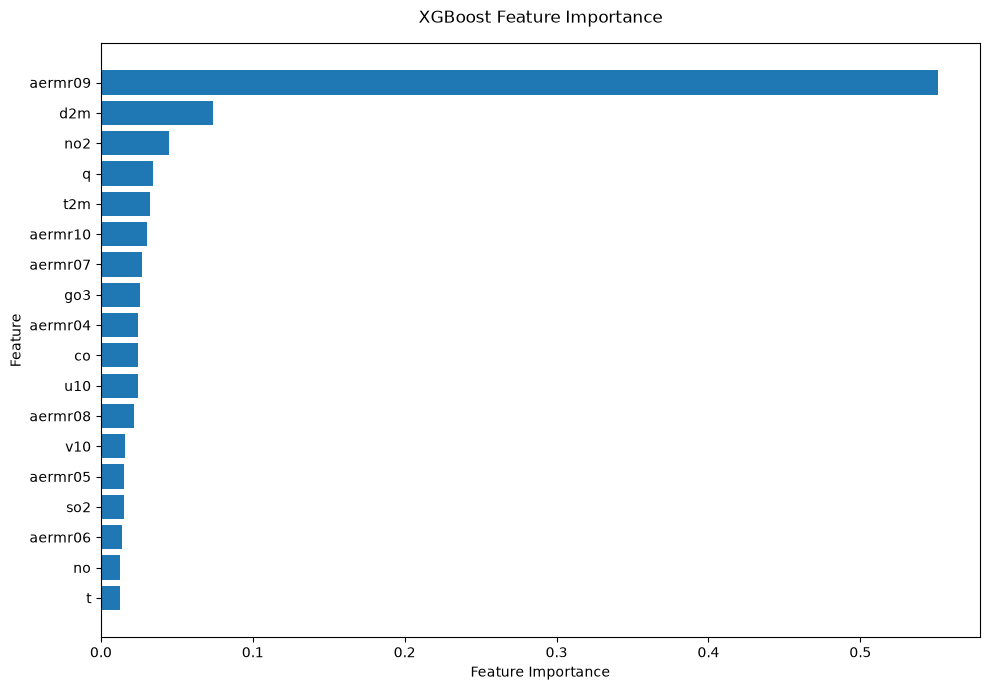

In [72]:
# Lets visualize these feature importance

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance",pad=15)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("plots/Modelling_plots/XGB_feature_importance.png",dpi = 300,bbox_inches = 'tight')
plt.show()

In [ ]:
                                # SEASONAL PERFORMANCE ANALYSIS of XGBoost#
# since performing this seasonal analysis 1 week after the work is done, i'm analyzing few thing required

In [ ]:
df.columns

Index(['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
       'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'time', 'step', 'hybrid',
       'latitude', 'longitude', 'valid_time', 'co', 'aermr04', 'aermr05',
       'aermr06', 'aermr09', 'aermr07', 'aermr10', 'aermr08', 'no2', 'no',
       'go3', 'q', 'so2', 't', 'number', 'surface', 'u10', 'v10', 'd2m', 't2m',
       'sp'],
      dtype='str')

In [18]:
df[['Timestamp','PM2.5 (µg/m³)']].head()

,Timestamp,PM2.5 (µg/m³)
0,2016-01-01 05:30:00,518.080
1,2016-01-01 08:30:00,387.000
2,2016-01-01 11:30:00,234.835
3,2016-01-01 14:30:00,144.420
4,2016-01-01 17:30:00,254.585


In [19]:
df[['Timestamp','PM2.5 (µg/m³)']].tail()

,Timestamp,PM2.5 (µg/m³)
29217,2025-12-31 08:30:00,201.5
29218,2025-12-31 11:30:00,189.0
29219,2025-12-31 14:30:00,249.5
29220,2025-12-31 17:30:00,309.5
29221,2025-12-31 20:30:00,399.0


In [20]:
# To check the test set date range

test_size = len(x2_test)

test_timestamps = df['Timestamp'].iloc[-test_size:]

print("Test set starts:", test_timestamps.iloc[0])
print("Test set ends:", test_timestamps.iloc[-1])
print("Number of test observations:", 
len(test_timestamps))


Test set starts: 2024-01-01 08:30:00
Test set ends: 2025-12-31 20:30:00
Number of test observations: 5845


In [21]:
# Define seasons

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Pre-Monsoon"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

In [23]:
# Convert Timestamp to datetime
season_test["Timestamp"] = pd.to_datetime(season_test["Timestamp"])

# Add season column
season_test["Season"] = season_test["Timestamp"].dt.month.map(get_season)

season_test.head()

,Timestamp,Actual_PM25,Season
0,2024-01-01 08:30:00,161.125,Winter
1,2024-01-01 11:30:00,178.875,Winter
2,2024-01-01 14:30:00,224.875,Winter
3,2024-01-01 17:30:00,195.000,Winter
4,2024-01-01 20:30:00,273.790,Winter


In [24]:
season_test["Predicted_PM25"] = results_exp2["XGBoost"]
season_test.head()

,Timestamp,Actual_PM25,Season,Predicted_PM25
0,2024-01-01 08:30:00,161.125,Winter,131.903305
1,2024-01-01 11:30:00,178.875,Winter,183.569305
2,2024-01-01 14:30:00,224.875,Winter,271.866058
3,2024-01-01 17:30:00,195.000,Winter,229.884552
4,2024-01-01 20:30:00,273.790,Winter,236.260742


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

season_results = []

for season in season_test["Season"].unique():
    
    data = season_test[season_test["Season"] == season]
    
    y_actual = data["Actual_PM25"]
    y_pred = data["Predicted_PM25"]
    
    season_results.append({
        "Season": season,
        "R²": r2_score(y_actual, y_pred),
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": mean_squared_error(y_actual, y_pred) ** 0.5,
        "Observations": len(data)
    })

season_results_df = pd.DataFrame(season_results)

season_results_df

,Season,R²,MAE,RMSE,Observations
0,Winter,0.481417,67.188552,89.529016,1445
1,Pre-Monsoon,-0.029427,38.680361,54.646469,1472
2,Monsoon,0.088285,26.377806,38.026966,1952
3,Post-Monsoon,0.484738,68.759740,100.391093,976


In [26]:
from xgboost import XGBRegressor

final_xgb = XGBRegressor(
    learning_rate=0.05,
    max_depth=5,
    n_estimators=200,
    random_state=42
)

In [27]:
final_xgb.fit(x2_train, y2_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
y_pred_tuned = final_xgb.predict(x2_test)

In [29]:
print("R²:", r2_score(y2_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y2_test, y_pred_tuned))
print("RMSE:", mean_squared_error(y2_test, y_pred_tuned) ** 0.5)

R²: 0.658933590342506
MAE: 44.408007791859276
RMSE: 66.9533158638165


In [30]:
season_test["Predicted_PM25"] = y_pred_tuned

In [31]:
season_results = []

for season in season_test["Season"].unique():

    data = season_test[season_test["Season"] == season]

    y_actual = data["Actual_PM25"]
    y_pred = data["Predicted_PM25"]

    season_results.append({
        "Season": season,
        "R²": r2_score(y_actual, y_pred),
        "MAE": mean_absolute_error(y_actual, y_pred),
        "RMSE": mean_squared_error(y_actual, y_pred) ** 0.5,
        "Observations": len(data)
    })

season_results_df = pd.DataFrame(season_results)

season_results_df

,Season,R²,MAE,RMSE,Observations
0,Winter,0.527990,64.236984,85.414235,1445
1,Pre-Monsoon,0.026784,38.536920,53.133572,1472
2,Monsoon,0.192682,24.731077,35.783630,1952
3,Post-Monsoon,0.528329,63.259176,96.050777,976
